In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load SBIN dataset
df = pd.read_csv("../data/raw/SBIN.csv")

# Convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Sort chronologically
df = df.sort_values("Date").reset_index(drop=True)

print("Shape:", df.shape)
print("\nStart Date:", df["Date"].min())
print("End Date:", df["Date"].max())

df.head()

Shape: (2878, 7)

Start Date: 2015-01-01 00:00:00
End Date: 2026-08-24 00:00:00


,Date,Adj Close,Close,High,Low,Open,Volume
0,2015-01-01,274.924988,314.000000,315.000000,310.700012,312.450012,6138488
1,2015-01-02,276.019440,315.250000,318.299988,314.350006,314.350006,9935094
2,2015-01-05,273.830566,312.750000,316.799988,312.100006,316.250000,9136716
3,2015-01-06,262.579651,299.899994,311.100006,298.700012,310.000000,15329257
4,2015-01-07,262.798492,300.149994,302.549988,295.149994,300.000000,15046745


In [3]:
# Select the Close price
data = df[["Close"]].values

# 80% training, 20% testing
train_size = int(len(data) * 0.8)

train_data = data[:train_size]
test_data = data[train_size:]

print("Total records:", len(data))
print("Training records:", len(train_data))
print("Testing records:", len(test_data))

print("\nTrain period:")
print(df["Date"].iloc[0], "to", df["Date"].iloc[train_size - 1])

print("\nTest period:")
print(df["Date"].iloc[train_size], "to", df["Date"].iloc[-1])

Total records: 2878
Training records: 2302
Testing records: 576

Train period:
2015-01-01 00:00:00 to 2024-05-02 00:00:00

Test period:
2024-05-03 00:00:00 to 2026-08-24 00:00:00


In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Load dataset
df = pd.read_csv("../data/raw/SBIN.csv")

# Convert Date column
df["Date"] = pd.to_datetime(df["Date"])

# Sort by date
df = df.sort_values("Date").reset_index(drop=True)

# Create 80/20 chronological split
split_index = int(len(df) * 0.8)

train = df.iloc[:split_index].copy()
test = df.iloc[split_index:].copy()

# Select Close prices
train_close = train[["Close"]]
test_close = test[["Close"]]

# Scale
scaler = MinMaxScaler(feature_range=(0, 1))

train_scaled = scaler.fit_transform(train_close)
test_scaled = scaler.transform(test_close)

# Check everything
print("Dataset shape:", df.shape)
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Train scaled shape:", train_scaled.shape)
print("Test scaled shape:", test_scaled.shape)

Dataset shape: (2878, 7)
Train shape: (2302, 7)
Test shape: (576, 7)
Train scaled shape: (2302, 1)
Test scaled shape: (576, 1)


In [8]:
LOOKBACK = 60

X_train = []
y_train = []

for i in range(LOOKBACK, len(train_scaled)):
    X_train.append(train_scaled[i - LOOKBACK:i, 0])
    y_train.append(train_scaled[i, 0])

X_train = np.array(X_train)
y_train = np.array(y_train)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nFirst sequence:")
print(X_train[0][:10])

print("\nTarget:")
print(y_train[0])

X_train shape: (2242, 60)
y_train shape: (2242,)

First sequence:
[0.24020907 0.24204947 0.23836867 0.21944934 0.21981742 0.22673734
 0.22430802 0.23005007 0.22710542 0.22651651]

Target:
0.17108360545065887


In [9]:
# Combine the last 60 training values with test values
test_input = np.concatenate(
    (train_scaled[-LOOKBACK:], test_scaled),
    axis=0
)

X_test = []
y_test = []

for i in range(LOOKBACK, len(test_input)):
    X_test.append(test_input[i - LOOKBACK:i, 0])
    y_test.append(test_input[i, 0])

X_test = np.array(X_test)
y_test = np.array(y_test)

print("Test input shape:", test_input.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\nExpected test predictions:", len(X_test))

Test input shape: (636, 1)
X_test shape: (576, 60)
y_test shape: (576,)

Expected test predictions: 576


In [10]:
# Reshape data for GRU
X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nX_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2242, 60, 1)
y_train shape: (2242,)

X_test shape: (576, 60, 1)
y_test shape: (576,)


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, GRU, Dropout, Dense
from tensorflow.keras.optimizers import Adam

# Build GRU model
model = Sequential([
    Input(shape=(LOOKBACK, 1)),

    GRU(50),

    Dropout(0.2),

    Dense(25, activation="relu"),

    Dense(1)
])

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mean_squared_error"
)

# Display model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 50)                  │           7,950 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 25)                  │           1,275 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9,251 (36.14 KB)

 Trainable params: 9,251 (36.14 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - loss: 0.0212 - val_loss: 0.0014
Epoch 2/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0013 - val_loss: 7.5810e-04
Epoch 3/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0010 - val_loss: 8.5246e-04
Epoch 4/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 8.2236e-04 - val_loss: 5.9034e-04
Epoch 5/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 7.0940e-04 - val_loss: 0.0018
Epoch 6/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 7.1682e-04 - val_loss: 0.0011
Epoch 7/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 6.7742e-04 - val_loss: 4.5746e-04
Epoch 8/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 5.3899e-04 - val_loss: 0.0011
Epoch 9/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 4.6132e-04 - val_loss: 3.6189e-04
Epoch 10/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 5.0878e-04 - val_loss: 0.0013
Epoch 11/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 4.4120e-04 - val_loss: 5.7279e

In [13]:
# Make predictions
predictions_scaled = model.predict(X_test)

# Convert predictions back to actual price scale
predictions = scaler.inverse_transform(predictions_scaled)

# Convert actual values back to actual price scale
actual_prices = scaler.inverse_transform(
    y_test.reshape(-1, 1)
)

print("Predictions shape:", predictions.shape)
print("Actual prices shape:", actual_prices.shape)

print("\nFirst 5 predictions:")

for i in range(5):
    print(
        f"Actual: ₹{actual_prices[i][0]:.2f} | "
        f"Predicted: ₹{predictions[i][0]:.2f}"
    )

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
Predictions shape: (576, 1)
Actual prices shape: (576, 1)

First 5 predictions:
Actual: ₹831.45 | Predicted: ₹822.30
Actual: ₹807.80 | Predicted: ₹825.14
Actual: ₹801.90 | Predicted: ₹813.86
Actual: ₹810.80 | Predicted: ₹804.43
Actual: ₹819.80 | Predicted: ₹804.47


In [14]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

# Calculate metrics
mae = mean_absolute_error(actual_prices, predictions)
rmse = np.sqrt(mean_squared_error(actual_prices, predictions))
mape = mean_absolute_percentage_error(actual_prices, predictions) * 100
r2 = r2_score(actual_prices, predictions)

print("===== GRU FORECAST RESULTS =====")
print(f"MAE: ₹{mae:.2f}")
print(f"RMSE: ₹{rmse:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"R² Score: {r2:.4f}")

===== GRU FORECAST RESULTS =====
MAE: ₹11.81
RMSE: ₹16.14
MAPE: 1.32%
R² Score: 0.9819


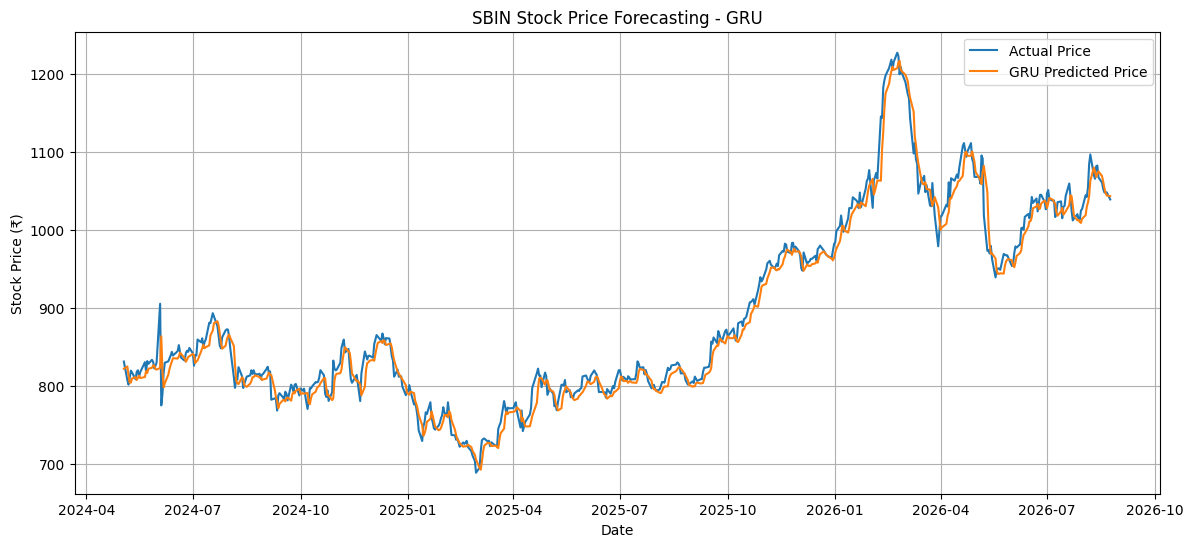

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    test["Date"],
    actual_prices.flatten(),
    label="Actual Price"
)

plt.plot(
    test["Date"],
    predictions.flatten(),
    label="GRU Predicted Price"
)

plt.title("SBIN Stock Price Forecasting - GRU")
plt.xlabel("Date")
plt.ylabel("Stock Price (₹)")

plt.legend()
plt.grid(True)

plt.show()

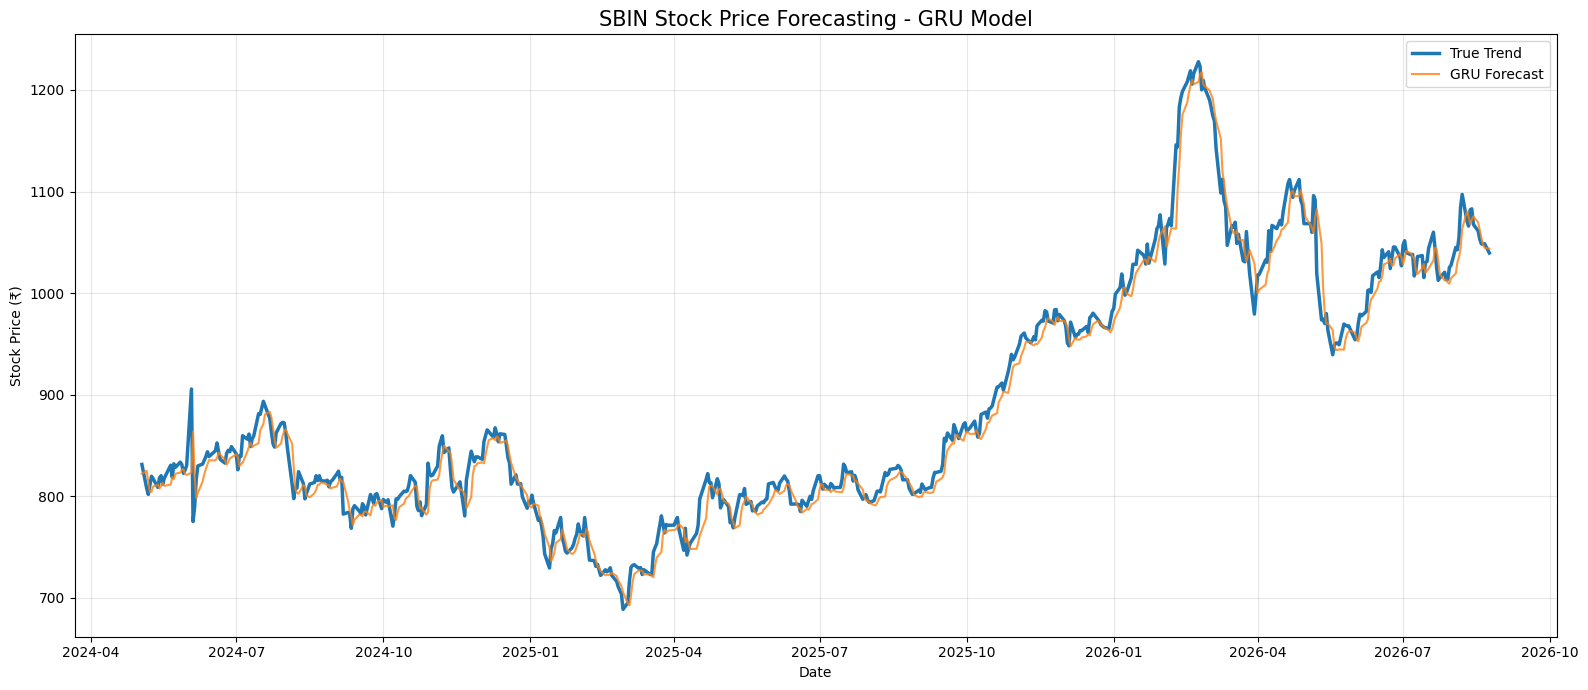

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 7))

# Actual / True trend
plt.plot(
    test["Date"],
    actual_prices.flatten(),
    label="True Trend",
    linewidth=2.5
)

# GRU Forecast
plt.plot(
    test["Date"],
    predictions.flatten(),
    label="GRU Forecast",
    linewidth=1.5,
    alpha=0.8
)

plt.title("SBIN Stock Price Forecasting - GRU Model", fontsize=15)
plt.xlabel("Date")
plt.ylabel("Stock Price (₹)")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()